# Notebook 02 - Synthetic Data Generation Pipeline

**Authors:** Ivo Rambaldi & Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

---

## Overview

This notebook implements **Goal 2** of the project: given the preprocessed training dataset produced by Goal 1, generate multiple synthetic datasets using four distinct synthesis strategies. The methods implemented are shown in the table below.

| Method | Type | Key property |
|--------|------|--------------|
| **Gaussian Copula** | Statistical | Lightweight baseline; explicit correlation structure |
| **CTGAN** | Deep generative (GAN) | Mode-specific normalisation; conditional generation |
| **TVAE** | Deep generative (VAE) | Stable training; good joint structure |
| **SMOTE** | Oversampling | Minority-class focused; interpolation-based; class-balancing |

The synthetic datasets produced here are the direct input for **Notebook 04**, which runs the TSTR (Train on Synthetic, Test on Real) evaluation matrix.

---

### About the target variable

The raw Aequitas dataset contains **no pre-built binary target column**. The dataset provides continuous performance scores (`score_MAT`, `score_LEN`, `score_ING`) and their ordinal level variants (1-4).

The binary classification target is constructed by **Notebook 01** by applying a percentile threshold to the score, following the methodology of Marrero et al. (ECAI 2024), which discretises performance into quartiles to define excellence (upper tail, $\geq 75$-th percentile) and underperformance (lower tail, $\leq 25$-th percentile) detection tasks.

Our project focuses on the **excellence detection task**: a student is labelled positive (`target_high_perf = 1`) if their `score_MAT` is $\geq$ the $75$-th percentile of the training split. The threshold is computed on the training set only to prevent data leakage.

The threshold and target column name are fully configurable via `config.yaml`:
```yaml
target:
  score_column: score_MAT
  percentile:   75
  column_name:  target_high_perf
```

---

### Notebook output

This noteboook produces four CSV files written to `results/synthetic/<method>/synthetic_<method>.csv`:

```
results/synthetic/
 |- copula/synthetic_copula.csv
 |- ctgan/synthetic_ctgan.csv
 |- tvae/synthetic_tvae.csv
 |- smote/synthetic_smote.csv
```

## 1. Environment Setup

### 1.1 Path and import setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd


# Ensure the project root is on sys.path so 'src' imports resolve correctly
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



from src.utils.config import load_config
from src.utils.logging import get_logger
from src.utils.prerequisites import check_prerequisites

logger = get_logger('notebook_02')
check_prerequisites()

# Suppress SDV FutureWarning about metadata API
warnings.filterwarnings('ignore', category=FutureWarning, module='sdv')
warnings.filterwarnings('ignore', category=UserWarning,   module='sdv')

logger.info("Environment ready. Project root: %s", PROJECT_ROOT)

Prerequisites check (requirements.txt): 16 OK, 0 missing, 0 version-mismatched.
2026-07-24 23:08:58 | INFO     | notebook_02 | Environment ready. Project root: C:\Users\tomma\Desktop\petrellirambaldi2526


### 1.2 Load configuration

In [2]:
# Load config.yaml
cfg = load_config(PROJECT_ROOT / 'config' / 'config.yaml')

# Print key config values for reproducibility
print('=== Configuration summary ===')
print(f"  seed            : {cfg['seed']}")
print(f"  train_data      : {cfg['paths']['train_data']}")
print(f"  synthetic_dir   : {cfg['paths']['synthetic_dir']}")
print(f"  target column   : {cfg['dataset']['target_column']}")
print(f"  n_synthetic     : {cfg['generation']['n_synthetic_samples']}  (None = match train size)")
print(f"  methods         : {[k for k, _ in cfg['generation']['methods'].items()]}")


=== Configuration summary ===
  seed            : 42
  train_data      : C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv
  synthetic_dir   : C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic
  target column   : target_high_perf
  n_synthetic     : None  (None = match train size)
  methods         : ['ctgan', 'tvae', 'gaussian_copula', 'smote']


## 2. Loading the Training Dataset

We load the preprocessed training dataset produced by **Notebook 01** (Goal 1).

### 2.1 MNAR decision

We deliberately **do not impute** missing values in the family questionnaire block (`f_mother_education_level`, `f_father_education_level`, `f_ESCS`, etc.) because the dataset paper (Giovanelli et al., 2026) establishes that these missingness patterns are **MNAR** (Missing Not At Random): they reflect social exclusion, meaning that families from disadvantaged socioeconomic backgrounds are more likely to decline to answer sensitive questions out of fear or stigma.

Imputing MNAR values would suppress the very signal that indicates which students are most at risk. This is an *ethical* choice, not merely a technical one. We pass missing values directly to the synthesizers and record how each method handles them in Section 5.

### 2.2 Why exclude performance score columns from synthesis

The columns `score_MAT`, `level_MAT`, `score_LEN`, `level_LEN`, `score_ING`, `level_ING` are listed under `dataset.performance_columns` in `config.yaml` and are excluded from the features passed to the synthesizers. The reason is subtle but important:

The binary target `target_high_perf` was derived directly from `score_MAT` (score $\geq 75$-th percentile). If we included `score_MAT` in synthesis, any generative model would trivially learn to reconstruct the target from the score, inflating utility metrics. More importantly, the performance scores are the **outcome variables** in the longitudinal design of paper17,
not inputs. What we want to synthesise is the student's circumstance and contextual profile; the target should be predicted from that profile by a downstream classifier.

In [3]:
from src.data.loader import load_dataset, describe_dataset

# drop_id_columns=True removes questionnaire/school IDs (no distributional signal).
# Performance score columns are handled separately below.
train_df_full = load_dataset(cfg['paths']['train_data'], cfg, drop_id_columns=True)

# Drop performance score columns before synthesis
perf_cols = [c for c in cfg['dataset'].get('performance_columns', []) if c in train_df_full.columns]
train_df = train_df_full.drop(columns=perf_cols)

print(f'Full loaded shape : {train_df_full.shape}')
print(f'Dropped perf cols : {perf_cols}')
print(f'For synthesis     : {train_df.shape}')
print()
describe_dataset(train_df, cfg)

2026-07-24 23:08:58 | INFO     | src.data.loader | Loading dataset from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv


2026-07-24 23:08:58 | INFO     | src.data.loader | Loaded  58128 rows x 48 columns


Full loaded shape : (58128, 48)
Dropped perf cols : []
For synthesis     : (58128, 48)

  Dataset summary
  Shape : 58,128 rows x 48 columns
  Target: 'target_high_perf'  ->  {0: 43594, 1: 14534}

  Missing values (9 columns with > 0% missing):
    s_birth_country                                         78.4%
    f_frequency_of_see_adult_read                           35.5%
    f_father_occupation                                     34.7%
    f_father_education_level                                32.7%
    f_mother_occupation                                     30.7%
    f_mother_education_level                                27.8%
    f_ESCS                                                  26.3%
    f_extent_of_books_at_home                               25.8%
    p_percentage_of_teachers_changed_school_last_year       5.7%

  Protected attributes (12 present):
    s_gender                                                {'MALE': 29356, 'FEMALE': 28772}  [missing=0]
    s_birth_countr

In [4]:
# Target distribution should be ~25% positive for a 75th-percentile threshold
target = cfg['dataset']['target_column']
counts = train_df[target].value_counts()

print(f'Target distribution ({target}):')
print(counts.to_string())
print(f'Positive rate: {train_df[target].mean():.1%}  (expected ~25% for 75th-pct threshold)')

Target distribution (target_high_perf):
target_high_perf
0    43594
1    14534
Positive rate: 25.0%  (expected ~25% for 75th-pct threshold)


## 3. Methodological Framing: Why These Four Methods?

Our choice of synthesis strategies covers three distinct paradigms. This is deliberate: by comparing methods across paradigms, we can attribute changes in fairness and utility to the *type* of generation rather than to any single implementation.

### 3.1 Gaussian Copula (statistical baseline)

A copula models marginal distributions and their correlations separately (Sklar's theorem). The Gaussian Copula assumes that correlations between variables, once normalised to uniform marginals, follow a multivariate Gaussian distribution.

**Why include it?** It is fully interpretable (the covariance matrix is directly inspectable), fast, and provides a ceiling estimate for how much of the utility/fairness loss is attributable to simple distributional distortion vs. deep-model artefacts.

**Known limitation:** The Gaussian correlation assumption may fail for heavily skewed or multi-modal features.

### 3.2 CTGAN (Conditional GAN for tabular data)

CTGAN addresses two core challenges in tabular synthesis:
1. **Multi-modal continuous distributions**: handled by mode-specific normalisation (fitting a Gaussian mixture and normalising each mode separately).
2. **Imbalanced categorical columns**: handled by a conditional vector that oversamples under-represented categories during training.

**Why include it?** It is the de-facto standard deep generative model for tabular data and the most-cited baseline in the synthetic data literature.

**Known limitation:** GAN training instability; mode collapse possible on
sparse high-cardinality features.

Encoder maps rows to a continuous latent space (μ, σ); decoder reconstructs rows from
samples of that latent distribution. Same preprocessing as CTGAN.

**Strengths:** Training is stable (no adversarial dynamics); good joint-distribution
modelling in low-data regimes when classes are balanced.

**Minority-class collapse as key limitation:** TVAE optimises
an evidence lower bound (reconstruction + KL regularisation). Reconstruction error is
*averaged over rows*, so a low-frequency category contributes little to the loss. With
our imbalanced target (~25% positive), the decoder minimises its objective by almost
always emitting the majority class, and on our data it collapses the positive class
**entirely** (synthetic positive rate ≈ 0%). Crucially, this is **not** a bug in our
pipeline: it occurs on identical data and metadata where CTGAN preserves the ~25% minority.
The difference is mechanistic — CTGAN's *conditional vector with training-by-sampling* was
designed specifically to force the model to generate every category of a discrete column
in proportion, whereas vanilla TVAE has no such safeguard.

We **report this as a result rather than fixing it.** It is precisely the kind of loss our
project sets out to measure: a widely-used, off-the-shelf synthesiser that, under realistic
class imbalance, produces a dataset on which the high-performer detection task becomes
impossible. Section 9 detects the collapse automatically and excludes TVAE from the TSTR
matrix; Goal 4 reports it as a generation failure.

### 3.4 SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE is *not* a generative model. It is an oversampling technique that adds synthetic minority-class rows by interpolating between k-nearest neighbours in feature space.

**Why include it?** SMOTE is widely used in practice as a data augmentation technique. By including it, we can empirically test whether its class-balancing property helps or hurts fairness relative to methods that model the full joint distribution.

**Ethical note:** SMOTE's interpolation is defined over the feature space of the *minority class only*. For this dataset the minority class may correspond to a specific demographic group (e.g., students from low-SES families who score below the threshold). Interpolating *within* this group may introduce artefacts that distort the representation of those subgroups in ways that impact fairness metrics. We document this in Section 5.

---

### 3.5 Key design decision: equal sample size

All methods are configured to produce the **same number of synthetic rows as the training set** (controlled by `generation.n_synthetic_samples: null` in `config.yaml`). This ensures that downstream utility/fairness comparisons are not confounded by different dataset sizes.

The one exception is SMOTE: it *adds* rows to achieve class balance, so its output will be larger than the other methods if the training data is imbalanced. We document the resulting size and class distribution explicitly in the output section.

## 4. Hyperparameters and Configuration

All hyperparameters are defined in `config/config.yaml`. We read and display them here to ensure the notebook output is a self-contained record of the experiment configuration.

Note: we intentionally do **not** tune hyperparameters per method. Our goal is to compare the *inherent* fairness/utility properties of each approach, not to optimise any single method. Tuning would introduce a confound.

In [5]:
print('=== Generation hyperparameters ===')
gen_cfg = cfg['generation']
print(f"  n_synthetic_samples : {gen_cfg['n_synthetic_samples']}")
print()
for method, params in gen_cfg['methods'].items():
    print(f'  [{method}]')
    for k, v in params.items():
        print(f'    {k}: {v}')
    print()

=== Generation hyperparameters ===
  n_synthetic_samples : None

  [ctgan]
    epochs: 300
    batch_size: 500

  [tvae]
    epochs: 300
    batch_size: 500

  [gaussian_copula]
    none: 0

  [smote]
    k_neighbors: 5



## 5. Running the Generation Pipeline

In [6]:
from src.generation.metadata import build_metadata


methods_cfg = cfg["generation"]["methods"]
synthetic_datasets: dict[str, pd.DataFrame] = {}

# Build SDV metadata once shared by all SDV-based generators.
logger.info("Building SDV metadata...")
metadata = build_metadata(train_df, cfg)

2026-07-24 23:09:07 | INFO     | notebook_02 | Building SDV metadata...


2026-07-24 23:09:07 | INFO     | src.generation.metadata | Metadata built: 32 categorical, 16 numerical columns


### 5.1 CTGAN

In [7]:
from src.generation.ctgan_gen import generate_ctgan
from src.utils.config import get_synthetic_output_path

logger.info("Running CTGAN...")
output_path = get_synthetic_output_path(cfg, "ctgan")
synthetic_datasets["ctgan"] = generate_ctgan(
    train_df, metadata, cfg, output_path
)

2026-07-24 23:09:07 | INFO     | notebook_02 | Running CTGAN...


2026-07-24 23:09:07 | INFO     | src.generation.ctgan_gen | CTGAN: fitting on 58128 rows (epochs=300, batch_size=500, seed=42)...


  0%|          | 0/300 [00:00<?, ?it/s]

Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]

Gen. (-01.66) | Discrim. (+00.03):   0%|          | 0/300 [00:22<?, ?it/s]

...

Gen. (-01.30) | Discrim. (+00.16): 100%|█████████▉| 299/300 [2:00:11<00:26, 26.60s/it]

Gen. (-01.30) | Discrim. (+00.16): 100%|██████████| 300/300 [2:00:11<00:00, 26.70s/it]

Gen. (-01.30) | Discrim. (+00.16): 100%|██████████| 300/300 [2:00:11<00:00, 24.04s/it]

2026-07-25 01:14:23 | INFO     | src.generation.ctgan_gen | CTGAN: sampling 58128 synthetic rows...


2026-07-25 01:14:30 | INFO     | src.generation.ctgan_gen | CTGAN: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv  (58128 rows)


### 5.2 TVAE

In [8]:
from src.generation.tvae_gen import generate_tvae

logger.info("Running TVAE...")
output_path = get_synthetic_output_path(cfg, "tvae")
synthetic_datasets["tvae"] = generate_tvae(
    train_df, metadata, cfg, output_path
)

2026-07-25 01:14:30 | INFO     | notebook_02 | Running TVAE...


2026-07-25 01:14:30 | INFO     | src.generation.tvae_gen | TVAE: fitting on 58128 rows (epochs=300, batch_size=500, seed=42)...


  0%|          | 0/300 [00:00<?, ?it/s]

Loss: +00.00:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +99.99:   0%|          | 0/300 [00:07<?, ?it/s]

...

Loss: +42.71: 100%|█████████▉| 299/300 [59:51<00:15, 15.87s/it]

Loss: +42.71: 100%|██████████| 300/300 [59:51<00:00, 16.06s/it]

Loss: +42.71: 100%|██████████| 300/300 [59:51<00:00, 11.97s/it]

2026-07-25 02:19:12 | INFO     | src.generation.tvae_gen | TVAE: sampling 58128 synthetic rows...


2026-07-25 02:19:17 | INFO     | src.generation.tvae_gen | TVAE: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\tvae\synthetic_tvae.csv  (58128 rows)


### 5.3 Gaussian Copula

In [9]:
from src.generation.copula_gen import generate_gaussian_copula

logger.info("Running Gaussian Copula...")
output_path = get_synthetic_output_path(cfg, "gaussian_copula")
synthetic_datasets["gaussian_copula"] = generate_gaussian_copula(
    train_df, metadata, cfg, output_path
)

2026-07-25 02:19:17 | INFO     | notebook_02 | Running Gaussian Copula...


2026-07-25 02:19:17 | INFO     | src.generation.copula_gen | GaussianCopula: fitting on 58128 rows...


2026-07-25 02:20:39 | INFO     | src.generation.copula_gen | GaussianCopula: sampling 58128 synthetic rows...


2026-07-25 02:20:55 | INFO     | src.generation.copula_gen | GaussianCopula: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\copula\synthetic_copula.csv  (58128 rows)


### 5.4 SMOTE

In [10]:
from src.generation.smote_gen import generate_smote


logger.info("=" * 50)
logger.info("Running SMOTE...")
output_path = get_synthetic_output_path(cfg, "smote")
synthetic_datasets["smote"] = generate_smote(
    train_df, cfg, output_path
)

2026-07-25 02:20:56 | INFO     | notebook_02 | ==================================================


2026-07-25 02:20:56 | INFO     | notebook_02 | Running SMOTE...


2026-07-25 02:20:56 | INFO     | src.generation.smote_gen | SMOTE: fitting on 58128 rows (k_neighbors=5, seed=42)...


2026-07-25 02:20:56 | INFO     | src.generation.smote_gen | Categorical column indices: [0, 4, 22, 23, 31, 46]


2026-07-25 02:20:56 | INFO     | src.generation.smote_gen | SMOTE: filled NaNs in 9 columns for kNN computation.


2026-07-25 02:21:17 | INFO     | src.generation.smote_gen | SMOTE: resampled to 87188 rows  (original: 58128)


2026-07-25 02:21:17 | INFO     | src.generation.smote_gen | Class distribution after resampling: {0: 43594, 1: 43594}


2026-07-25 02:21:20 | INFO     | src.generation.smote_gen | SMOTE: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote\synthetic_smote.csv  (87188 rows)


### 5.4b SMOTE (low-perf variant)

CTGAN/TVAE/GaussianCopula above never condition on the target column — they jointly model the full feature set, so `target_low_perf` is already synthesized (unconditioned) alongside `target_high_perf` in each of their outputs. SMOTE is different: it explicitly 1:1-balances whichever column is `cfg["dataset"]["target_column"]` (currently `target_high_perf`). To get a synthetic dataset that is actually balanced for the underperformance task (Goal 3b/4b), we rerun SMOTE with the target swapped, on a copy of `cfg` so the rest of this notebook keeps using `target_high_perf`. Output is written to a separate directory (`results/synthetic/smote_low_perf/`) so it never overwrites `synthetic_smote.csv`.

Set `generation.run_low_perf_smote: false` in `config.yaml` to skip this cell if you only need the excellence-detection (target_high_perf) pipeline.

In [11]:
import copy

if cfg["generation"].get("run_low_perf_smote", True):
    cfg_low_perf = copy.deepcopy(cfg)
    cfg_low_perf["dataset"]["target_column"] = cfg["target"]["low_column_name"]

    logger.info("=" * 50)
    logger.info("Running SMOTE (low-perf variant)...")
    output_path = get_synthetic_output_path(cfg_low_perf, "smote_low_perf")
    synthetic_datasets["smote_low_perf"] = generate_smote(
        train_df, cfg_low_perf, output_path
    )

    low_target = cfg_low_perf["dataset"]["target_column"]
    smote_low_df = synthetic_datasets["smote_low_perf"]
    print(f"SMOTE (low-perf) class distribution ({low_target}): "
          f"{smote_low_df[low_target].value_counts().to_dict()}")
else:
    logger.info("generation.run_low_perf_smote is false — skipping low-perf SMOTE rerun.")

2026-07-25 02:21:20 | INFO     | notebook_02 | ==================================================


2026-07-25 02:21:20 | INFO     | notebook_02 | Running SMOTE (low-perf variant)...


2026-07-25 02:21:20 | INFO     | src.generation.smote_gen | SMOTE: fitting on 58128 rows (k_neighbors=5, seed=42)...


2026-07-25 02:21:20 | INFO     | src.generation.smote_gen | Categorical column indices: [0, 4, 22, 23, 31, 46]


2026-07-25 02:21:20 | INFO     | src.generation.smote_gen | SMOTE: filled NaNs in 9 columns for kNN computation.


2026-07-25 02:21:41 | INFO     | src.generation.smote_gen | SMOTE: resampled to 87192 rows  (original: 58128)


2026-07-25 02:21:41 | INFO     | src.generation.smote_gen | Class distribution after resampling: {0: 43596, 1: 43596}


2026-07-25 02:21:44 | INFO     | src.generation.smote_gen | SMOTE: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote_low_perf\synthetic_smote_low_perf.csv  (87192 rows)


SMOTE (low-perf) class distribution (target_low_perf): {0: 43596, 1: 43596}


### 5.5 Output summary

In [12]:
print('=== Generation complete ===')
for method, df in synthetic_datasets.items():
    pos_rate = df[target].mean() if target in df.columns else float('nan')
    print(
        f'  {method:<20}  {len(df):>6,} rows x {df.shape[1]} cols  '
        f'positive_rate={pos_rate:.1%}'
    )

=== Generation complete ===
  ctgan                 58,128 rows x 48 cols  positive_rate=24.5%
  tvae                  58,128 rows x 48 cols  positive_rate=23.6%
  gaussian_copula       58,128 rows x 48 cols  positive_rate=25.1%
  smote                 87,188 rows x 48 cols  positive_rate=50.0%
  smote_low_perf        87,192 rows x 48 cols  positive_rate=16.7%


## 6. Fidelity Evaluation

Before passing the synthetic datasets to Goal 3 (utility and fairness measurement), we perform a **fidelity sanity check**: does the synthetic data look statistically similar to the real training data?

We compute three complementary fidelity metrics:

| Metric | Scope | What it measures |
|--------|-------|------------------|
| **MMD** (Maximum Mean Discrepancy) | Numerical columns | Overall distributional distance between real and synthetic (kernel-based, 0 = identical) |
| **Spearman correlation MAE** | Numerical columns | Mean absolute difference in rank correlations between real and synthetic |
| **KL divergence** | Categorical columns | Per-column divergence of category frequencies |

These are *fidelity* metrics. They are distinct from *utility* metrics (i.e. does training on synthetic -> good performance on real?) and *fairness* metrics (does synthetic preserve equity across protected groups?), which are computed in Goal 3.

These metrics are used *within* Goal 2 to sanity-check each synthesizer before passing the data to Goal 3 (utility/fairness evaluation). A synthesizer that fails basic fidelity checks is not worth evaluating further.

**Interpretation guide:**
- A low MMD does not guarantee good utility: the model could hallucinate
realistic-looking marginals while destroying joint structure.
- A high KL divergence on a protected attribute column (e.g., `s_gender`)
is a direct early warning of potential fairness distortion.

In [13]:
from src.generation.fidelity import compute_fidelity_report, pprint_fidelity_report

fidelity_reports = {}
for method, syn_df in synthetic_datasets.items():
    report = compute_fidelity_report(train_df, syn_df, cfg, method_name=method)
    fidelity_reports[method] = report
    pprint_fidelity_report(report)

2026-07-25 02:21:44 | INFO     | src.generation.fidelity | Computing fidelity report for method=ctgan


2026-07-25 02:21:49 | INFO     | src.generation.fidelity |   MMD=0.0897  corr_MAE=0.0784  mean_KL=0.0309



  Fidelity Report - method: ctgan
  Real rows     : 58,128
  Synthetic rows: 58,128
  MMD (RBF)     : 0.089720  (lower is better)
  Corr MAE      : 0.0784  (lower is better)
  Mean KL div   : 0.0309  (lower is better)

  Per-column KL divergences (categorical):
    s_birth_country                                          0.0981
    f_frequency_of_see_adult_read                            0.0795
    p_island                                                 0.0285
    target_low_perf                                          0.0090
    p_public_or_private                                      0.0008
    target_high_perf                                         0.0001
    s_gender                                                 0.0001

  Column statistics (numerical columns - top 10):
    a3a                                            mean: real=1.015 / syn=1.004  std:  real=0.122 / syn=0.066
    s_birth_year                                   mean: real=1.079 / syn=1.056  std:  real=0.322 / 

2026-07-25 02:21:53 | INFO     | src.generation.fidelity |   MMD=0.0947  corr_MAE=0.0624  mean_KL=0.1591



  Fidelity Report - method: tvae
  Real rows     : 58,128
  Synthetic rows: 58,128
  MMD (RBF)     : 0.094655  (lower is better)
  Corr MAE      : 0.0624  (lower is better)
  Mean KL div   : 0.1591  (lower is better)

  Per-column KL divergences (categorical):
    s_gender                                                 0.7770
    s_birth_country                                          0.1444
    f_frequency_of_see_adult_read                            0.0839
    p_island                                                 0.0675
    p_public_or_private                                      0.0306
    target_low_perf                                          0.0097
    target_high_perf                                         0.0005

  Column statistics (numerical columns - top 10):
    a3a                                            mean: real=1.015 / syn=1.009  std:  real=0.122 / syn=0.095
    s_birth_year                                   mean: real=1.079 / syn=1.104  std:  real=0.322 / s

...


  Fidelity Report - method: gaussian_copula
  Real rows     : 58,128
  Synthetic rows: 58,128
  MMD (RBF)     : 0.132131  (lower is better)
  Corr MAE      : 0.0817  (lower is better)
  Mean KL div   : 0.0013  (lower is better)

  Per-column KL divergences (categorical):
    s_birth_country                                          0.0092
    f_frequency_of_see_adult_read                            0.0001
    p_island                                                 0.0000
    target_low_perf                                          0.0000
    p_public_or_private                                      0.0000
    target_high_perf                                         0.0000
    s_gender                                                 0.0000

  Column statistics (numerical columns - top 10):
    a3a                                            mean: real=1.015 / syn=1.016  std:  real=0.122 / syn=0.124
    s_birth_year                                   mean: real=1.079 / syn=1.080  std:  rea

2026-07-25 02:22:02 | INFO     | src.generation.fidelity |   MMD=0.0474  corr_MAE=0.0136  mean_KL=0.2807



  Fidelity Report - method: smote
  Real rows     : 58,128
  Synthetic rows: 87,188
  MMD (RBF)     : 0.047417  (lower is better)
  Corr MAE      : 0.0136  (lower is better)
  Mean KL div   : 0.2807  (lower is better)

  Per-column KL divergences (categorical):
    s_birth_country                                          1.5022
    f_frequency_of_see_adult_read                            0.3044
    target_high_perf                                         0.1308
    target_low_perf                                          0.0223
    p_public_or_private                                      0.0036
    p_island                                                 0.0009
    s_gender                                                 0.0008

  Column statistics (numerical columns - top 10):
    a3a                                            mean: real=1.015 / syn=1.013  std:  real=0.122 / syn=0.110
    s_birth_year                                   mean: real=1.079 / syn=1.060  std:  real=0.322 / 

2026-07-25 02:22:06 | INFO     | src.generation.fidelity |   MMD=0.0631  corr_MAE=0.0179  mean_KL=0.2920



  Fidelity Report - method: smote_low_perf
  Real rows     : 58,128
  Synthetic rows: 87,192
  MMD (RBF)     : 0.063069  (lower is better)
  Corr MAE      : 0.0179  (lower is better)
  Mean KL div   : 0.2920  (lower is better)

  Per-column KL divergences (categorical):
    s_birth_country                                          1.4948
    f_frequency_of_see_adult_read                            0.3916
    target_low_perf                                          0.1308
    target_high_perf                                         0.0223
    p_public_or_private                                      0.0036
    p_island                                                 0.0004
    s_gender                                                 0.0002

  Column statistics (numerical columns - top 10):
    a3a                                            mean: real=1.015 / syn=1.016  std:  real=0.122 / syn=0.119
    s_birth_year                                   mean: real=1.079 / syn=1.098  std:  real

### 6.1 Protected attribute fidelity

We specifically inspect whether the synthesizers preserve the distributions of protected attributes, namely the circumstances $C_1$-$C_{12}$. Distortions here directly imply that fairness metrics computed downstream will differ from those on real data.

In [14]:
# Per protected-attribute KL divergence across all methods
protected_attrs = cfg['dataset']['protected_attributes']
cat_cols = set(cfg['dataset'].get('categorical_columns', []))

# Collect KL divergences for categorical protected attributes
protected_kl_table = {}
for attr in protected_attrs:
    if attr not in train_df.columns:
        continue
    if train_df[attr].dtype != object and attr not in cat_cols:
        continue  # numerical protected attributes: skip KL, covered by MMD
    protected_kl_table[attr] = {}
    for method, report in fidelity_reports.items():
        kl = report['kl_divergences'].get(attr, float('nan'))
        protected_kl_table[attr][method] = kl

if protected_kl_table:
    kl_df = pd.DataFrame(protected_kl_table).T
    print('KL divergence for categorical protected attributes (lower is better):')
    print(kl_df.to_string(float_format='{:.4f}'.format))
else:
    print('No categorical protected attributes with KL data available.')

KL divergence for categorical protected attributes (lower is better):
                               ctgan   tvae  gaussian_copula  smote  smote_low_perf
s_gender                      0.0001 0.7770           0.0000 0.0008          0.0002
s_birth_country               0.0981 0.1444           0.0092 1.5022          1.4948
f_frequency_of_see_adult_read 0.0795 0.0839           0.0001 0.3044          0.3916
p_public_or_private           0.0008 0.0306           0.0000 0.0036          0.0036
p_island                      0.0285 0.0675           0.0000 0.0009          0.0004


## 7. Visualisations

Visual inspection of marginal distributions is a key sanity check. We plot the distribution of the target variable and selected protected attributes across all methods.

Figures are automatically saved to `results/figures/`.

2026-07-25 02:22:06 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\class_balance.png


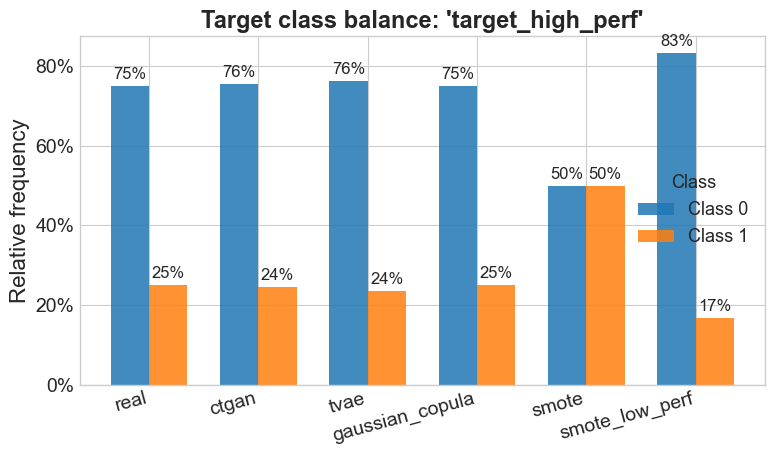

In [15]:
from src.utils.plotting import (
    plot_class_balance,
    plot_fidelity_summary,
    plot_marginal_distributions
)

# Class balance across methods
fig_balance = plot_class_balance(train_df, synthetic_datasets, cfg, save=True)
plt.show(); plt.close()

2026-07-25 02:22:07 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\fidelity_summary.png


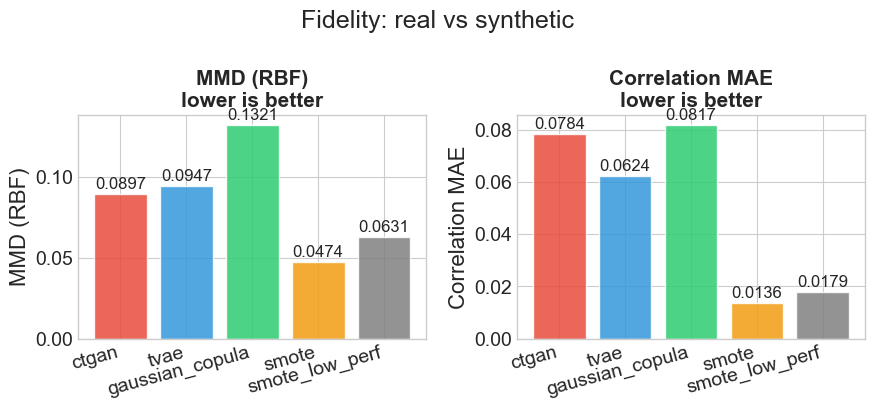

In [16]:
# Fidelity summary (MMD + corr MAE)
fig_fidelity = plot_fidelity_summary(list(fidelity_reports.values()), cfg, save=True)
plt.show(); plt.close()

2026-07-25 02:22:07 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\marginal_target_high_perf.png


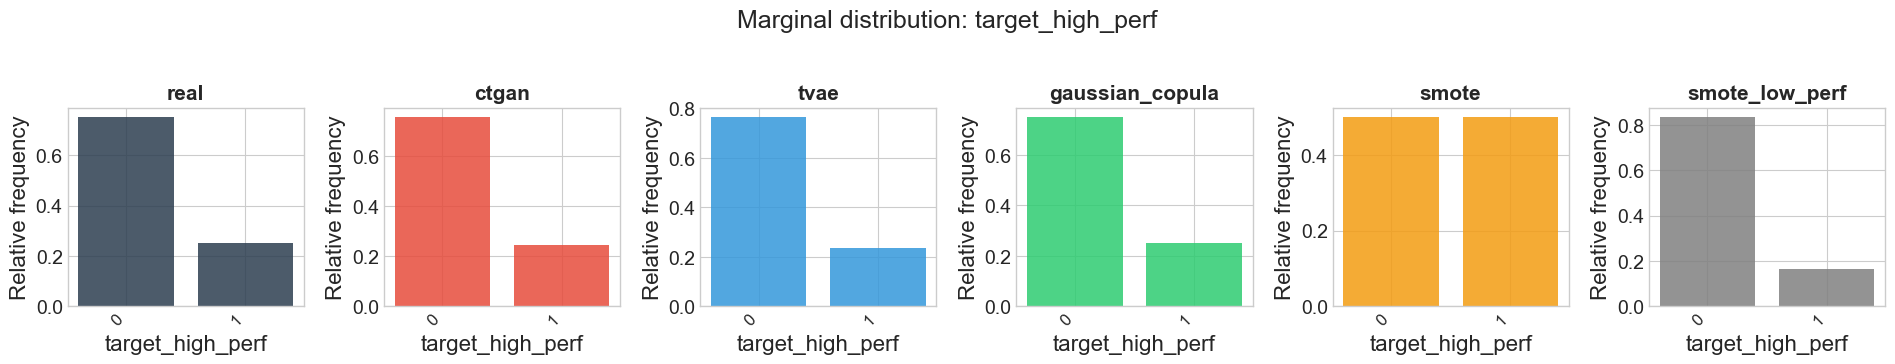

2026-07-25 02:22:08 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\marginal_s_gender.png


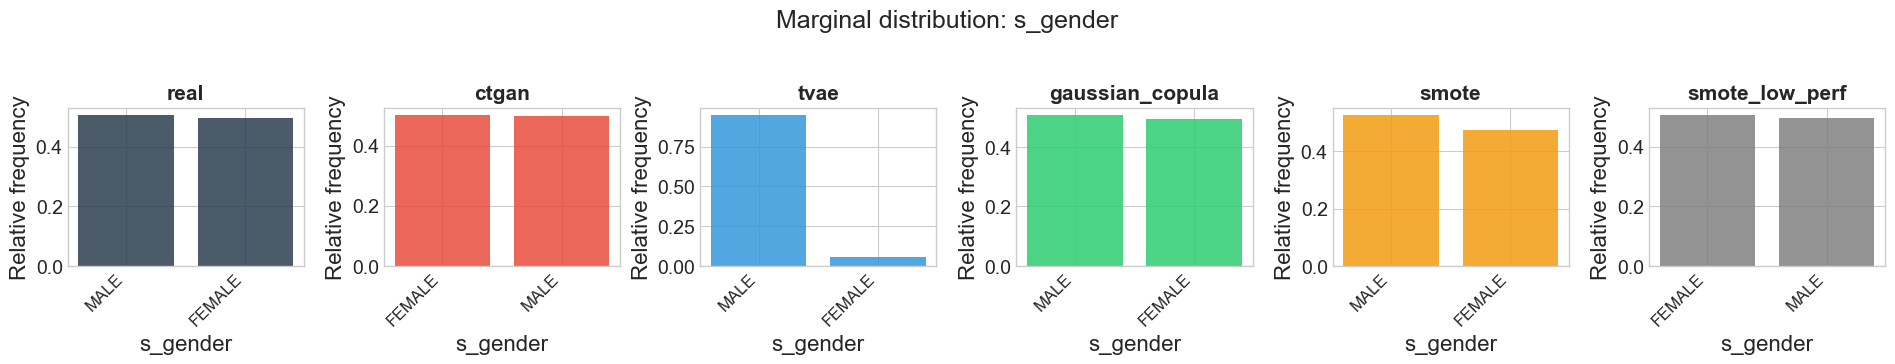

2026-07-25 02:22:09 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\marginal_p_public_or_private.png


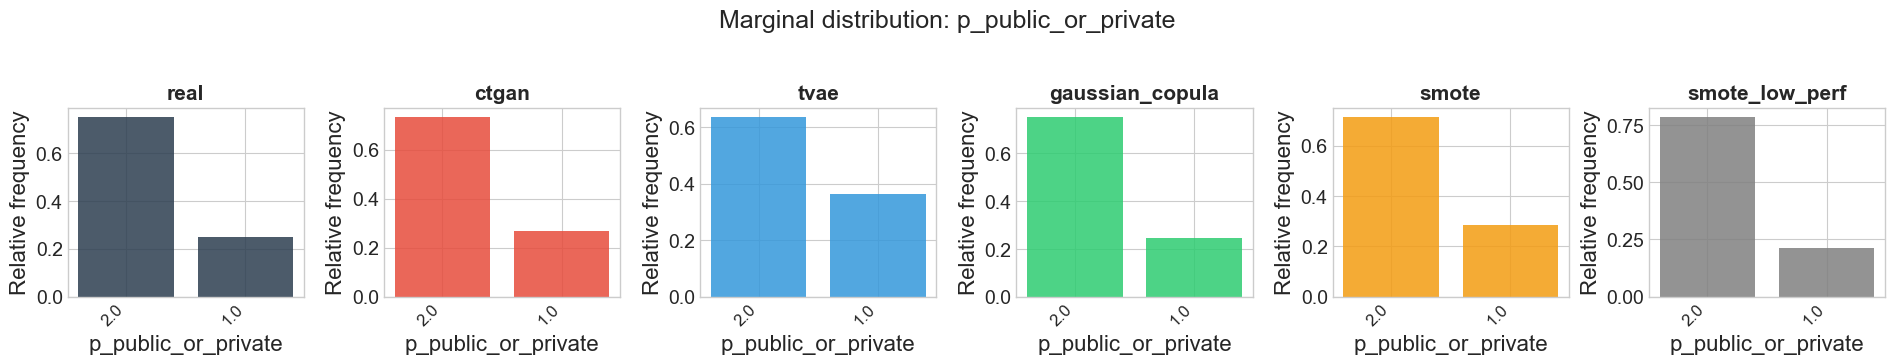

In [17]:
# Marginal distributions for the target column and two key protected attributes
cols_to_plot = [
    cfg['dataset']['target_column'],
    's_gender',
    'p_public_or_private',
]

for col in cols_to_plot:
    if col in train_df.columns:
        fig = plot_marginal_distributions(train_df, synthetic_datasets, col, cfg, save=True)
        plt.show(); plt.close()
    else:
        print(f'Column {col!r} not found in train_df... skipping.')

## 8. SMOTE: Special Considerations

SMOTE requires separate analysis because its semantics differ fundamentally from the other three methods.

### 8.1 Class balance change

SMOTE oversamples the **minority class** until class balance is achieved (1:1 ratio by default). This means:
- The synthetic dataset produced by SMOTE is typically *larger* than the training set.
- The target distribution in the synthetic set is artificially balanced, which is *not* representative of the real world.

This matters for our TSTR evaluation: a classifier trained on SMOTE-synthetic data may be calibrated for a 50/50 world, which could produce different fairness metric outcomes than a classifier trained on real-proportion data.

### 8.2 Representation of minority subgroups within the minority class

The minority class (top 25% performers) is not demographically uniform: it is disproportionately composed of students from high-SES backgrounds (high `f_ESCS`, tertiary-educated parents, more books at home). SMOTE interpolates *within* this already-privileged subpopulation, potentially creating synthetic students who cluster around the 'average high-SES high performer' and underrepresent the minority within the minority: high-performing students from disadvantaged backgrounds.

The analysis below quantifies this effect.

In [18]:
if 'smote' in synthetic_datasets:
    smote_df = synthetic_datasets['smote']
    target = cfg['dataset']['target_column']

    print('=== SMOTE class distribution ===')
    print(f'  Real    : {train_df[target].value_counts().to_dict()}')
    print(f'  SMOTE   : {smote_df[target].value_counts().to_dict()}')
    print(f'  Real size  : {len(train_df):,} rows')
    print(f'  SMOTE size : {len(smote_df):,} rows (+{len(smote_df)-len(train_df):,} synthetic)')

    # Check if protected attribute distributions differ between real minority
    # class and SMOTE synthetic minority class
    print('\n=== Protected attribute distributions - minority class only ===')
    print('  (Positive = high performer, i.e. score_MAT >= 75th percentile)')
    protected_attrs_present = [a for a in cfg['dataset']['protected_attributes'] if a in train_df.columns]
    for attr in protected_attrs_present:
        real_min  = train_df.loc[train_df[target]==0, attr].value_counts(normalize=True)
        smote_min = smote_df.loc[smote_df[target]==0, attr].value_counts(normalize=True)
        print(f'  {attr}:')
        print(f'    Real  minority: {real_min.to_dict()}')
        print(f'    SMOTE minority: {smote_min.to_dict()}')
        print()
else:
    print('SMOTE was not enabled.')

=== SMOTE class distribution ===
  Real    : {0: 43594, 1: 14534}
  SMOTE   : {0: 43594, 1: 43594}
  Real size  : 58,128 rows
  SMOTE size : 87,188 rows (+29,060 synthetic)

=== Protected attribute distributions - minority class only ===
  (Positive = high performer, i.e. score_MAT >= 75th percentile)
  s_gender:
    Real  minority: {'FEMALE': 0.5049318713584439, 'MALE': 0.4950681286415562}
    SMOTE minority: {'FEMALE': 0.5049318713584439, 'MALE': 0.4950681286415562}

  s_birth_country:
    Real  minority: {'ESP': 0.9114249037227214, 'VEN': 0.015083440308087292, 'CUB': 0.008130081300813009, 'ITA': 0.008130081300813009, 'COL': 0.006097560975609756, 'CHN': 0.005776636713735558, 'ARG': 0.0043859649122807015, 'MAR': 0.0043859649122807015, 'URY': 0.003209242618741977, 'BOL': 0.002888318356867779, 'GBR': 0.002246469833119384, 'PER': 0.0019255455712451862, 'DOM': 0.0018185708172871202, 'ECU': 0.0017115960633290544, 'BRA': 0.0016046213093709885, 'ROU': 0.0014976465554129225, 'RUS': 0.00149764